In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque
import matplotlib.animation as animation

2025-03-30 07:17:51.464461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743328071.547081     877 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743328071.578965     877 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [4]:
print(jax.default_backend())

gpu


In [5]:
# Define the function to compute the gradient of jax's relu
def grad_relu(x):
    # Use jax's relu function and calculate its gradient
    return jax.grad(nn.relu)(x)

# Example point
x = jnp.array(-0.000000)

# Compute the gradient of jax's ReLU at x
gradient_at_x = grad_relu(x)

print(f"The gradient of ReLU at x = {x} is {gradient_at_x}")


The gradient of ReLU at x = -0.0 is 0.0


In [6]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [7]:
t0, tfinal = 0.0, 0.5

In [8]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [9]:
@jax.jit
def calc_x1tt_x2tt(x1, x2, x1t, x2t) :

    a1 = (l2 / l1) * (m2 / (m1 + m2)) * jnp.cos(x1 - x2)
    a2 = (l1 / l2) * jnp.cos(x1 - x2)
    f1 = -(l2 / l1) * (m2 / (m1 + m2)) * (x2t**2) * jnp.sin(x1 - x2) - (grav / l1) * jnp.sin(x1)
    f2 = (l1 / l2) * (x1t**2) * jnp.sin(x1 - x2) - (grav / l2) * jnp.sin(x2)
    g1 = (f1 - a1 * f2) / (1 - a1 * a2)
    g2 = (f2 - a2 * f1) / (1 - a1 * a2)

    return g1, g2

In [10]:
@jax.jit
def Hcalc_xyt(x1, x2, y1, y2) :

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))


    return x1_t, x2_t, y1_t, y2_t

In [11]:
@jax.jit
def doublePendulum(w, t):
    
    x1, x2, x1_t, x2_t = w

    x1_tt, x2_tt = calc_x1tt_x2tt(x1, x2, x1_t, x2_t)
    
    dwdt = [x1_t, x2_t, x1_tt, x2_tt]

    return dwdt

In [12]:
def HdoublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

In [13]:
@jax.jit
def Hcalc_y1y2(x1, x2, y1, y2) :

    y1_val = (m1 + m2)*l1**2*y1 + m2*l1*l2*y2*jnp.cos(x1 - x2)
    y2_val = m2*l2**2*y2 + m2*l1*l2*y1*jnp.cos(x1 - x2)

    return y1_val, y2_val

In [14]:
@jax.jit
def calc_E(x1, x2, y1, y2) :

    V = -(m1 + m2)*grav*l1*jnp.cos(x1) - m2*grav*l2*jnp.cos(x2)
    K = 0.5*m1*l1**2*y1**2 + 0.5*m2*(l1**2*y1**2 + l2**2*y2**2 + 2*l1*l2*y1*y2*jnp.cos(x1 - x2))

    E = V + K

    return E

In [15]:
@jax.jit
def Hcalc_H(x1, x2, y1, y2) :

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2)) - \
        (m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    return H

In [16]:
@jax.jit
def calc_linmomentum(x1, x2, y1, y2) :

    Px = m1 * l1 * y1 * jnp.cos(x1) + m2 * (l1 * y1 * jnp.cos(x1) + l2 * y2 * jnp.cos(x2))
    
    Py = m1 * l1 * y1 * jnp.sin(x1) + m2 * (l1 * y1 * jnp.sin(x1) + l2 * y2 * jnp.sin(x2))
    
    return Px, Py

In [17]:
@jax.jit
def calc_angmomentum(x1, x2, y1, y2) :
    
    L = (m1 * l1**2 * y1) + m2 * (l1**2 * y1 + l2**2 * y2 + 2* l1 * l2 * y1 * y2)

    return L



In [18]:
# Vmin = -(m1 + m2)*grav*l1*1.0 - m2*grav*l2*1.0
# Vmax = -(m1 + m2)*grav*l1*-1.0 - m2*grav*l2*-1.0

# Kmin = 0.5*m1*l1**2*0.0**2 + 0.5*m2*(l1**2*0.0**2 + l2**2*0.0**2 + 2*l1*l2*1.0*1.0*-1.0)
# Kmax = 0.5*m1*l1**2*1.0**2 + 0.5*m2*(l1**2*1.0**2 + l2**2*1.0**2 + 2*l1*l2*1.0*1.0*1.0)

# Emin = Vmin + Kmin
# Emax = Vmax + Kmax
Emin = -29.43
Emax = -13.40

Hmin = -29.43
Hmax = -13.40

print(Emin, Emax)

-29.43 -13.4


In [19]:
# n = 500
# t = np.linspace(t0, tfinal, n)

# x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))

# data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
# data_rk = np.reshape(data_rk, (-1,))
# t_rk = t

# Hy1_init, Hy2_init = Hcalc_y1y2(x1_init, x2_init, y1_init, y2_init)

# Hdata_rk = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
# Hdata_rk = np.reshape(Hdata_rk, (-1,))
# Ht_rk = t

# sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
# x1_rk, x2_rk, y1_rk, y2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
# y1_rk, y2_rk = Hcalc_y1y2(x1_rk, x2_rk, y1_rk, y2_rk)

# p1_rk, p2_rk = calc_linmomentum(x1_rk, x2_rk, y1_rk, y2_rk)
# L_rk = calc_angmomentum(x1_rk, x2_rk, y1_rk, y2_rk)

# Hsol_rk = odeint(HdoublePendulum, Hdata_rk, Ht_rk, rtol = 1e-13, atol = 1e-13)
# Hx1_rk, Hx2_rk, Hy1_rk, Hy2_rk = Hsol_rk[:, 0], Hsol_rk[:, 1], Hsol_rk[:, 2], Hsol_rk[:, 3]

In [20]:
# fig = plt.figure(figsize=(12, 10))

# plt.subplot(1, 4, 1)
# plt.tight_layout()
# plt.plot(t, L_rk)
# plt.xlabel("△x1")
# plt.grid()

# plt.subplot(1, 4, 2)
# plt.tight_layout()
# plt.plot(t, x2_rk - Hx2_rk)
# plt.xlabel("△x2")
# plt.grid()

# plt.subplot(1, 4, 3)
# plt.tight_layout()
# plt.plot(t, y1_rk - Hy1_rk)
# plt.xlabel("△y1")
# plt.grid()

# plt.subplot(1, 4, 4)
# plt.tight_layout()
# plt.plot(t, y2_rk -  Hy2_rk)
# plt.xlabel("△y2")
# plt.grid()

In [21]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [22]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [23]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [24]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [25]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    x1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    x2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    y1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    y2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Es = calc_E(x1s, x2s, y1s, y2s)

    ode_points = np.column_stack((ode_points, Es))
    zsensors = np.column_stack((x1s, x2s, y1s, y2s))
    
    return (ode_points, zsensors)

In [26]:
def Hdefine_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    # x1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    # x2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    # y1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    # y2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    x1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    x2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    y1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    y2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Hs = Hcalc_H(x1s, x2s, y1s, y2s)

    ode_points = np.column_stack((ode_points, Hs))
    zsensors = np.column_stack((x1s, x2s, y1s, y2s))
    
    return (ode_points, zsensors)

In [27]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

E_colloc = de_points[:, -1]
Emin_colloc = np.min(E_colloc)
Emax_colloc = np.max(E_colloc)

print(Emin, Emin_colloc)
print(Emax, Emax_colloc)

(1000, 2) (1000, 4)
-29.43 -29.39670289302108
-13.4 -14.991485466490667


In [28]:
(Hde_points, Hzsensors) = Hdefine_collocation_points([t0, tfinal], 1000)
print(Hde_points.shape, Hzsensors.shape)


H_colloc = de_points[:, -1]
Hmin_colloc = np.min(H_colloc)
Hmax_colloc = np.max(H_colloc)

print(Emin, Hmin_colloc)
print(Emax, Hmax_colloc)

(1000, 2) (1000, 4)
-29.43 -29.39670289302108
-13.4 -14.991485466490667


In [29]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tE.ndim == 1:
      tE = jnp.reshape(tE, (1,-1)) 

    t_0 = tE[:, :1]
    E_0 = tE[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)  
      
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    b = t_0_norm
    # b = jnp.column_stack((t_0_norm, E_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [30]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return Vdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(Vvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Vvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Vloss(params, tE, z):   

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    y1_t_loss_w = 1.0
    y2_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0

    t_0 = tE[:, 0]
    E_0 = tE[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    y1_0 = z[:, 2]
    y2_0 = z[:, 3]

    x1 = Vvar(tE, z, 0, params)
    x2 = Vvar(tE, z, 1, params)
    y1 = Vvar(tE, z, 2, params)
    y2 = Vvar(tE, z, 3, params)

    dx1_tE = Vvar_t(tE, z, 0, params)
    dx2_tE = Vvar_t(tE, z, 1, params)
    dy1_tE = Vvar_t(tE, z, 2, params)
    dy2_tE = Vvar_t(tE, z, 3, params) 

    x1_t = dx1_tE[:, 0]
    x2_t = dx2_tE[:, 0]
    y1_t = dy1_tE[:, 0]
    y2_t = dy2_tE[:, 0]

    E = calc_E(x1, x2, y1, y2)
  
    x1_tt, x2_tt = calc_x1tt_x2tt(x1, x2, y1, y2)

    x1_t_loss = x1_t - y1
    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))

    x2_t_loss = x2_t - y2
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))

    y1_t_loss = y1_t - x1_tt
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))

    y2_t_loss = y2_t - x2_tt
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))

    E_loss = E - E_0
    E_loss = jnp.mean(jnp.square(E_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss

    total_loss = diff_loss + E_loss

    return total_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    tE = pdes
    
    return jax.value_and_grad(Vloss)(params, tE, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [31]:
def Vtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())

            params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [32]:
Vdeeponet = VDeepONet(t0, tfinal, Emin, Emax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

Vparams = Vdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [33]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(Vparam_count)

19960


In [34]:
# tree_info, shapes, Vparams_flat = flatten_pytree(Vparams)
# Vparams_flat = jnp.load("V_t0.5_5000_5000_ep_DP.npy")
# print(Vparams_flat.shape)
# Vparams = reconstruct_pytree(tree_info, shapes, Vparams_flat)

In [35]:
# epochs = 5000
# Vparams, Vloss = Vtrain_network(Vparams, de_points, zsensors, epochs)

# plt.semilogy(Vloss)
# plt.grid()

In [36]:
# testparams = copy.deepcopy(Vparams)

In [37]:
# _, _, Vparams_flat = flatten_pytree(Vparams)
# jnp.save("V_t0.5_1000_5000(-3)+2500(-4)_ep_DP", Vparams_flat)

In [38]:
# n = 500
# t = np.linspace(t0, tfinal, n)

# x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
# E_init = calc_E(x1_init, x2_init, y1_init, y2_init)

# model_data = np.column_stack([x1_init, x2_init, y1_init, y2_init])
# model_data = np.reshape(model_data, (-1,))
# model_data = np.repeat(np.expand_dims(model_data, axis=0), n, axis=0)

# E_data =  np.reshape(E_init, (-1,))
# E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)

# tE_data = np.column_stack([t, E_data])

# x1 = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, model_data, 0, Vparams)
# x2 = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, model_data, 1, Vparams)
# y1 = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, model_data, 2, Vparams)
# y2 = jax.vmap(Vvar_model, [0, 0, None, None])(tE_data, model_data, 3, Vparams)
# E = calc_E(x1, x2, y1, y2)

# t_rk = t
# data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
# data_rk = np.reshape(data_rk, (-1,))

# sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
# x1_rk, x2_rk, y1_rk, y2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
# E_rk = calc_E(x1_rk, x2_rk, y1_rk, y2_rk)

# fig = plt.figure(figsize=(12, 10))

# plt.subplot(1, 5, 1)
# plt.tight_layout()
# plt.plot(t, x1, label = 'Model')
# plt.plot(t, x1_rk, label = 'RK45')
# plt.xlabel("x1")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 2)
# plt.tight_layout()
# plt.plot(t, x2, label = 'Model')
# plt.plot(t, x2_rk, label = 'RK45')
# plt.xlabel("x2")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 3)
# plt.tight_layout()
# plt.plot(t, y1, label = 'Model')
# plt.plot(t, y1_rk, label = 'RK45')
# plt.xlabel("y1")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 4)
# plt.tight_layout()
# plt.plot(t, y2, label = 'Model')
# plt.plot(t, y2_rk, label = 'RK45')
# plt.xlabel("y2")
# plt.grid()
# plt.legend()

# plt.subplot(1, 5, 5)
# plt.tight_layout()
# plt.plot(t, E, label = 'Model')
# plt.plot(t, E_rk, label = 'RK45')
# plt.xlabel("E")
# plt.grid()
# plt.legend()

In [39]:
class HVDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tH, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tH.ndim == 1:
      tH = jnp.reshape(tH, (1,-1)) 

    t_0 = tH[:, :1]
    H_0 = tH[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
      
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    b = t_0_norm
    # b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [40]:
@partial(jax.jit, static_argnums=(2,))
def HVvar_model(t, z, component, params):
  return HVdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def HVvar(t, z, component, params):
  return jax.vmap(HVvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def HVvar_t(t, z, component, params):
  return jax.vmap(jax.grad(HVvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def HVloss(params, tH, z):   

    t_0 = tH[:, 0]
    H_0 = tH[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    y1_0 = z[:, 2]
    y2_0 = z[:, 3]

    x1 = HVvar(tH, z, 0, params)
    x2 = HVvar(tH, z, 1, params)
    y1 = HVvar(tH, z, 2, params)
    y2 = HVvar(tH, z, 3, params)

    dx1_tH = HVvar_t(tH, z, 0, params)
    dx2_tH = HVvar_t(tH, z, 1, params)
    dy1_tH = HVvar_t(tH, z, 2, params)
    dy2_tH = HVvar_t(tH, z, 3, params) 

    x1_t = dx1_tH[:, 0]
    x2_t = dx2_tH[:, 0]
    y1_t = dy1_tH[:, 0]
    y2_t = dy2_tH[:, 0]

    H = Hcalc_H(x1, x2, y1, y2)
  
    x1t, x2t, y1t, y2t = Hcalc_xyt(x1, x2, y1, y2)

    x1_t_loss = x1_t - x1t
    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))

    x2_t_loss = x2_t - x2t
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))

    y1_t_loss = y1_t - y1t
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))

    y2_t_loss = y2_t - y2t
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))

    H_loss = H - H_0
    H_loss = jnp.mean(jnp.square(H_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss

    total_loss = diff_loss + H_loss

    return total_loss

@jax.jit
def HVtrain_step(params, pdes, z):
    tH = pdes
    
    return jax.value_and_grad(HVloss)(params, tH, z)

@partial(jax.jit, static_argnums=(3,))
def HVoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [41]:
def HVtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = HVtrain_step(params, des_batch.numpy(), z_batch.numpy())

            params, opt_state = HVoptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [42]:
HVdeeponet = VDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

HVparams = HVdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [43]:
HVparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(HVparam_count)

19960


In [44]:
# epochs = 5000
# HVparams, HVloss = HVtrain_network(HVparams, Hde_points, Hzsensors, epochs)

# plt.semilogy(HVloss)
# plt.grid()

In [45]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tE.ndim == 1:
      tE = jnp.reshape(tE, (1,-1)) 

    t_0 = tE[:, :1]
    E_0 = tE[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)
   
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    x1t_0 = u[:, 2:3]
    x2t_0 = u[:, 3:]

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, E_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_x1t = trunk_net[:, 2*self.units:3*self.units]
    trunk_x2t = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_x1t = branch_net[:, 2*self.units:3*self.units]
    branch_x2t = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    x1t = CombineBranches()(trunk_x1t, branch_x1t)
    x2t = CombineBranches()(trunk_x2t, branch_x2t)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    x1t = HardConstraint(self.t0, self.tfinal, x1t_0)([t_0, x1t])
    x2t = HardConstraint(self.t0, self.tfinal, x2t_0)([t_0, x2t])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    x1t = jnp.reshape(x1t, (-1,))
    x2t = jnp.reshape(x2t, (-1,))

    return x1, x2, x1t, x2t

In [46]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t_temp(t, z, component, params):
  return jax.grad(var_model, 0)(t, z, component, params)[0]

@partial(jax.jit, static_argnums=(2,))
def var_tt(t, z, component, params):
    return jax.vmap(jax.grad(var_t_temp, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tE, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    y1_t_loss_w = 1.0
    y2_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0

    t_0 = tE[:, 0]
    E_0 = tE[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    y1_0 = z[:, 2]
    y2_0 = z[:, 3]

    x1 = var(tE, z, 0, params)
    x2 = var(tE, z, 1, params)
    y1 = var(tE, z, 2, params)
    y2 = var(tE, z, 3, params)

    dx1_tE = var_t(tE, z, 0, params)
    dx2_tE = var_t(tE, z, 1, params)
    dy1_tE = var_t(tE, z, 2, params)
    dy2_tE = var_t(tE, z, 3, params) 

    x1_t = dx1_tE[:, 0]
    x2_t = dx2_tE[:, 0]
    y1_t = dy1_tE[:, 0]
    y2_t = dy2_tE[:, 0]

    E = calc_E(x1, x2, y1, y2)
  
    x1_tt, x2_tt = calc_x1tt_x2tt(x1, x2, y1, y2)

    x1_t_loss = x1_t - y1
    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))

    x2_t_loss = x2_t - y2
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))

    y1_t_loss = y1_t - x1_tt
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))

    y2_t_loss = y2_t - x2_tt
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))

    E_loss = E - E_0
    E_loss = jnp.mean(jnp.square(E_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss

    total_loss = diff_loss + E_loss

    return total_loss

@jax.jit
def train_step(params, pdes, z):
    tE = pdes
    
    return jax.value_and_grad(loss)(params, tE, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [47]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [48]:
deeponet = DeepONet(t0, tfinal, Emin, Emax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [49]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

20000


In [50]:
# tree_info, shapes, params_flat = flatten_pytree(params)
# params_flat = jnp.load("P_t0.5_5000_5000_ep_DP.npy")
# print(params_flat.shape)
# params = reconstruct_pytree(tree_info, shapes, params_flat)

batch size: 100


I0000 00:00:1743328079.131905     877 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 117 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Loss in epoch 0: 7.510237955307612
Loss in epoch 100: 0.36226686245950235
Loss in epoch 200: 0.19149163744924813
Loss in epoch 300: 0.15386154851555917
Loss in epoch 400: 0.12225802073536586
Loss in epoch 500: 0.08661090325504302
Loss in epoch 600: 0.09318328668669534
Loss in epoch 700: 0.060137786877182846
Loss in epoch 800: 0.05400591624876367
Loss in epoch 900: 0.12920067797789492
Loss in epoch 1000: 0.0495394026971989
Loss in epoch 1100: 0.05165305311443773
Loss in epoch 1200: 0.04941116811058567
Loss in epoch 1300: 0.09484471341611385
Loss in epoch 1400: 0.03449859393410161
Loss in epoch 1500: 0.03111386763432338
Loss in epoch 1600: 0.02665043174626169
Loss in epoch 1700: 0.03109939481028515
Loss in epoch 1800: 0.028087363835690295
Loss in epoch 1900: 0.0869675851683392
Loss in epoch 2000: 0.04333028025468987
Loss in epoch 2100: 0.027186098841320026
Loss in epoch 2200: 0.026277620859135275
Loss in epoch 2300: 0.06908104102091163
Loss in epoch 2400: 0.046748120846439215


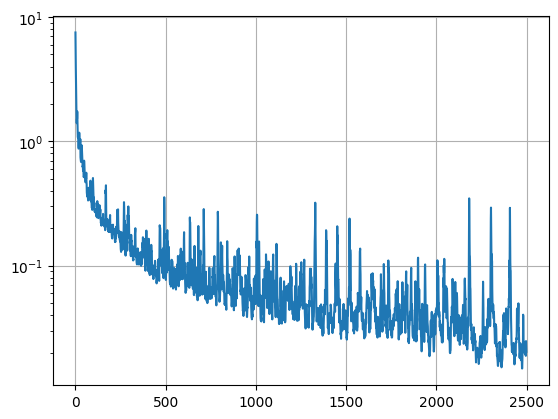

In [51]:
epochs = 2500
params, loss = train_network(params, de_points, zsensors, epochs)

plt.semilogy(loss)
plt.grid()

In [52]:
class HDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tH, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tH.ndim == 1:
      tH = jnp.reshape(tH, (1,-1)) 

    t_0 = tH[:, :1]
    H_0 = tH[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
      
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [53]:
@partial(jax.jit, static_argnums=(2,))
def Hvar_model(t, z, component, params):
  return Hdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Hvar(t, z, component, params):
  return jax.vmap(Hvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Hvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Hvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Hloss(params, tH, z):   

    t_0 = tH[:, 0]
    H_0 = tH[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    y1_0 = z[:, 2]
    y2_0 = z[:, 3]

    x1 = Hvar(tH, z, 0, params)
    x2 = Hvar(tH, z, 1, params)
    y1 = Hvar(tH, z, 2, params)
    y2 = Hvar(tH, z, 3, params)

    dx1_tH = Hvar_t(tH, z, 0, params)
    dx2_tH = Hvar_t(tH, z, 1, params)
    dy1_tH = Hvar_t(tH, z, 2, params)
    dy2_tH = Hvar_t(tH, z, 3, params) 

    x1_t = dx1_tH[:, 0]
    x2_t = dx2_tH[:, 0]
    y1_t = dy1_tH[:, 0]
    y2_t = dy2_tH[:, 0]

    H = Hcalc_H(x1, x2, y1, y2)
  
    x1t, x2t, y1t, y2t = Hcalc_xyt(x1, x2, y1, y2)

    x1_t_loss = x1_t - x1t
    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))

    x2_t_loss = x2_t - x2t
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))

    y1_t_loss = y1_t - y1t
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))

    y2_t_loss = y2_t - y2t
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))

    H_loss = H - H_0
    H_loss = jnp.mean(jnp.square(H_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss

    total_loss = diff_loss + H_loss

    return total_loss

@jax.jit
def Htrain_step(params, pdes, z):
    tH = pdes
    
    return jax.value_and_grad(Hloss)(params, tH, z)

@partial(jax.jit, static_argnums=(3,))
def Hoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [54]:
def Htrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = Htrain_step(params, des_batch.numpy(), z_batch.numpy())

            params, opt_state = Hoptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [55]:
Hdeeponet = HDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

Hparams = Hdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [56]:
Hparam_count = sum(x.size for x in jax.tree.leaves(Hparams))
print(Hparam_count)

20000


batch size: 100
Loss in epoch 0: 10.57922123400349
Loss in epoch 100: 0.10392481773618446
Loss in epoch 200: 0.06818876163019091
Loss in epoch 300: 0.05265741706820368
Loss in epoch 400: 0.03508537987730572
Loss in epoch 500: 0.025003427209784684
Loss in epoch 600: 0.022249949986706295
Loss in epoch 700: 0.024566370245578138
Loss in epoch 800: 0.019320267662727833
Loss in epoch 900: 0.012343946397229497
Loss in epoch 1000: 0.013158875070110489
Loss in epoch 1100: 0.016124305922195638
Loss in epoch 1200: 0.009644022270145956
Loss in epoch 1300: 0.009322946340537444
Loss in epoch 1400: 0.00853259236820711
Loss in epoch 1500: 0.00776459070422996
Loss in epoch 1600: 0.007455029393732349
Loss in epoch 1700: 0.005909069777779775
Loss in epoch 1800: 0.005696847248345691
Loss in epoch 1900: 0.00566068572422624
Loss in epoch 2000: 0.009646393676250498
Loss in epoch 2100: 0.01423775805057881
Loss in epoch 2200: 0.005938269021955775
Loss in epoch 2300: 0.0036074705772059647
Loss in epoch 2400: 0.

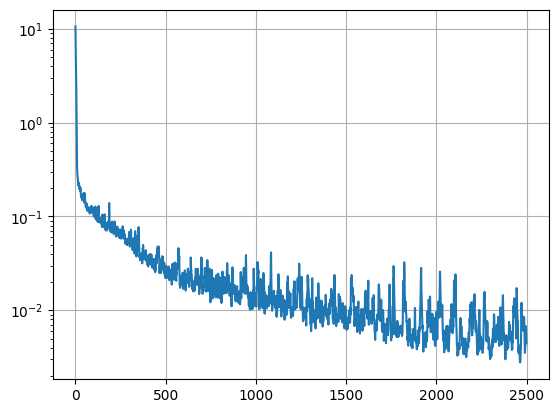

In [57]:
epochs = 2500
Hparams, Hloss = Htrain_network(Hparams, Hde_points, Hzsensors, epochs)

plt.semilogy(Hloss)
plt.grid()

In [58]:
# start = 0
# stop = 5000


# plt.semilogy(Vloss[start:stop])
# plt.semilogy(loss[start:stop])
# plt.semilogy(HVloss[start:stop])
# plt.semilogy(Hloss[start:stop])
# plt.legend(['Vanilla DN (Lagrangian)', 'Extended DN (Lagrangian)', \
#             'Vanilla DN (Hamiltonian)', 'Extended DN (Hamiltonian)'])
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error for Extended DeepONets")
# plt.grid()
# #plt.savefig('DoublePend_extended+Hextended_loss_5000ep.png')

In [59]:
# _, _, Hparams_flat = flatten_pytree(Hparams)
# jnp.save("H_t0.5_5000ep_DP", Hparams_flat)

In [60]:
tree_info, shapes, _ = flatten_pytree(params)
params_flat = jnp.load("P_t0.5_5000ep_DP.npy")
params_5000ep = reconstruct_pytree(tree_info, shapes, params_flat)

tree_info, shapes, _ = flatten_pytree(Hparams)
Hparams_flat = jnp.load("H_t0.5_5000ep_DP.npy")
Hparams_5000ep = reconstruct_pytree(tree_info, shapes, Hparams_flat)

In [61]:
@jax.jit
def f_func_newton(x, E_0) :

    x = jnp.reshape(x, (-1,))
    E_0 = jnp.reshape(E_0, (-1,))

    x1, x2, y1, y2  = x[0], x[1], x[2], x[3]
    E_0 = E_0[0]
    
    E = calc_E(x1, x2, y1, y2)
    
    f_val = E - E_0

    f = jnp.array([[f_val]])

    return f

In [62]:
@jax.jit
def gradf_func_newton(x, E_0) :

    x = jnp.reshape(x, (-1,))
    E_0 = jnp.reshape(E_0, (-1,))

    x1, x2, y1, y2  = x[0], x[1], x[2], x[3]
    E_0 = E_0[0]
    
    E = calc_E(x1, x2, y1, y2)
    
    dE_dx1 = m1*grav*l1*jnp.sin(x1) + m2*grav*l1*jnp.sin(x1) - m2*l1*l2*y1*y2*jnp.sin(x1-x2)
    dE_dx2 = m2*grav*l2*jnp.sin(x2) + m2*l1*l2*y1*y2*jnp.sin(x1-x2)  
    dE_dy1 = m1*(l1**2)*y1 + m2*(l1**2)*y1 + m2*l1*l2*y2*jnp.cos(x1-x2)
    dE_dy2 = m2*(l2**2)*y2 +  m2*l1*l2*y1*jnp.cos(x1-x2)

    df_dx1 = dE_dx1
    df_dx2 = dE_dx2
    df_dy1 = dE_dy1
    df_dy2 = dE_dy2

    grad_f = jnp.array([[df_dx1, df_dx2, df_dy1, df_dy2]])

    return grad_f

In [63]:
@jax.jit
def newtons_root(x, E_0) :

    iter_num = 0

    E_0 = jnp.reshape(E_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton(x, E_0)
        J = gradf_func_newton(x, E_0)
        J_inv = jnp.linalg.pinv(J)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

In [64]:
@jax.jit
def find_min_newton_E(x, E_0) :

    return jnp.squeeze(jax.vmap(newtons_root, (0, 0), 0)(x, E_0))

In [65]:
@jax.jit
def Hf_func_newton(x, H_0) :

    x = jnp.reshape(x, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    x1, x2, Hy1, Hy2  = x[0], x[1], x[2], x[3]
    H_0 = H_0[0]
    
    H = Hcalc_H(x1, x2, Hy1, Hy2)
    
    f_val = H - H_0

    f = jnp.array([[f_val]])

    return f

In [66]:
@jax.jit
def Hgradf_func_newton(x, H_0) :

    x = jnp.reshape(x, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    x1, x2, Hy1, Hy2  = x[0], x[1], x[2], x[3]
    H_0 = H_0[0]
    
    H = Hcalc_H(x1, x2, Hy1, Hy2)
    x1t, x2t, y1t, y2t = Hcalc_xyt(x1, x2, Hy1, Hy2)
    
    # A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    # h1 = (Hy1*Hy2*jnp.sin(x1 - x2))/A
    # h2 = (m2*(l2**2)*(Hy1**2) + (m1 + m2)*(l1**2)*(Hy2**2) - 2*m2*l1*l2*Hy1*Hy2*jnp.cos(x1 - x2))/(2*A**2)
    
    # dH_dx1 = m1*grav*l1*jnp.sin(x1) + m2*grav*l1*jnp.sin(x1) - m2*l1*l2*Hy1*Hy2*jnp.sin(x1-x2)
    # dH_dx2 = m2*grav*l2*jnp.sin(x2) + m2*l1*l2*Hy1*Hy2*jnp.sin(x1-x2)  
    # dH_dHy1 = m1*(l1**2)*Hy1 + m2*(l1**2)*Hy1 + m2*l1*l2*Hy2*jnp.cos(x1-x2)
    # dH_dHy2 = m2*(l2**2)*Hy2 +  m2*l1*l2*Hy1*jnp.cos(x1-x2)

    dH_dx1 = -y1t
    dH_dx2 = -y2t
    dH_dHy1 = x1t
    dH_dHy2 = x2t

    df_dx1 = dH_dx1
    df_dx2 = dH_dx2
    df_dHy1 = dH_dHy1
    df_dHy2 = dH_dHy2

    grad_f = jnp.array([[df_dx1, df_dx2, df_dHy1, df_dHy2]])

    return grad_f

In [67]:
@jax.jit
def Hnewtons_root(x, H_0) :

    iter_num = 0

    H_0 = jnp.reshape(H_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = Hf_func_newton(x, H_0)
        J = Hgradf_func_newton(x, H_0)
        J_inv = jnp.linalg.pinv(J)
        
        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

In [68]:
@jax.jit
def find_min_newton_H(x, H_0) :

    return jnp.squeeze(jax.vmap(Hnewtons_root, (0, 0), 0)(x, H_0))

In [69]:
class CVClosestPoint(nn.Module):

    E_0: float
    
    @nn.compact
    def __call__(self, inputs):

        z_min = find_min_newton_E(inputs, self.E_0)
    
        return z_min

In [70]:
class CVDeepONet(nn.Module):

  t0: float
  tfinal: float
  Emin: float
  Emax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tE.ndim == 1:
      tE = jnp.reshape(tE, (1,-1)) 

    t_0 = tE[:, :1]
    E_0 = tE[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    E_0_norm = Normalize(self.Emin, self.Emax)(E_0)
      
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, E_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    z = jnp.column_stack([x1, x2, y1, y2])
    z = CVClosestPoint(E_0)(z)

    x1 = z[:1]
    x2 = z[1:2]
    y1 = z[2:3]
    y2 = z[3:]

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [71]:
@partial(jax.jit, static_argnums=(2,))
def CVvar_model(t, z, component, params):
  return CVdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def CVvar(t, z, component, params):
  return jax.vmap(CVvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def CVvar_t(t, z, component, params):
  return jax.vmap(jax.grad(CVvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def CVloss(params, tE, z):   

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    y1_t_loss_w = 1.0
    y2_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    E_loss_w = 1.0

    t_0 = tE[:, 0]
    E_0 = tE[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    y1_0 = z[:, 2]
    y2_0 = z[:, 3]

    x1 = CVvar(tE, z, 0, params)
    x2 = CVvar(tE, z, 1, params)
    y1 = CVvar(tE, z, 2, params)
    y2 = CVvar(tE, z, 3, params)

    dx1_tE = CVvar_t(tE, z, 0, params)
    dx2_tE = CVvar_t(tE, z, 1, params)
    dy1_tE = CVvar_t(tE, z, 2, params)
    dy2_tE = CVvar_t(tE, z, 3, params) 

    x1_t = dx1_tE[:, 0]
    x2_t = dx2_tE[:, 0]
    y1_t = dy1_tE[:, 0]
    y2_t = dy2_tE[:, 0]

    E = calc_E(x1, x2, y1, y2)
  
    x1_tt, x2_tt = calc_x1tt_x2tt(x1, x2, y1, y2)

    x1_t_loss = x1_t - y1
    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))

    x2_t_loss = x2_t - y2
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))

    y1_t_loss = y1_t - x1_tt
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))

    y2_t_loss = y2_t - x2_tt
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))

    E_loss = E - E_0
    E_loss = jnp.mean(jnp.square(E_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss

    total_loss = diff_loss + E_loss

    return total_loss

@jax.jit
def CVtrain_step(params, pdes, z):
    tE = pdes
    
    return jax.value_and_grad(CVloss)(params, tE, z)

@partial(jax.jit, static_argnums=(3,))
def CVoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [72]:
def CVtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = CVtrain_step(params, des_batch.numpy(), z_batch.numpy())

            params, opt_state = CVoptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [73]:
CVdeeponet = CVDeepONet(t0, tfinal, Emin, Emax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

CVparams = CVdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [74]:
CVparam_count = sum(x.size for x in jax.tree.leaves(CVparams))
print(CVparam_count)

20000


In [75]:
CVparams = copy.deepcopy(params)

batch size: 100
Loss in epoch 0: 0.05664762181044524
Loss in epoch 100: 0.01448161360888237
Loss in epoch 200: 0.013647242752037318
Loss in epoch 300: 0.011592706439857743
Loss in epoch 400: 0.00938550520204306
Loss in epoch 500: 0.009672220231098457
Loss in epoch 600: 0.009863496514442828
Loss in epoch 700: 0.0076695462896791645
Loss in epoch 800: 0.0075533792521981225
Loss in epoch 900: 0.007623124101457553
Loss in epoch 1000: 0.006320633977705503
Loss in epoch 1100: 0.00731419730495084
Loss in epoch 1200: 0.0057288484760709005
Loss in epoch 1300: 0.005796105125074145
Loss in epoch 1400: 0.005895190415634283
Loss in epoch 1500: 0.012556867557472184
Loss in epoch 1600: 0.005025254973314837
Loss in epoch 1700: 0.005970459316689923
Loss in epoch 1800: 0.00491461739223494
Loss in epoch 1900: 0.004588904249410266
Loss in epoch 2000: 0.004561012778829221
Loss in epoch 2100: 0.008545192179034607
Loss in epoch 2200: 0.006161785077207708
Loss in epoch 2300: 0.005749964342097486
Loss in epoch 

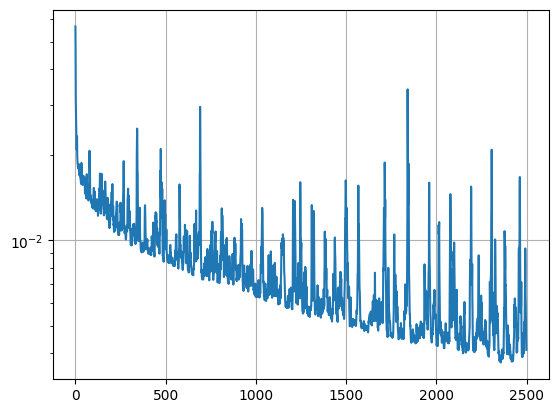

In [76]:
epochs = 2500
CVparams, CVloss = CVtrain_network(CVparams, de_points, zsensors, epochs)

plt.semilogy(CVloss[:])
plt.grid()

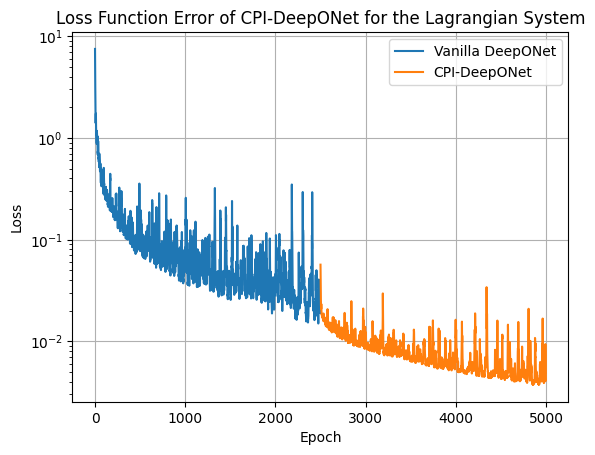

In [77]:
split = 2500
num_ep = np.arange(0, split, 1)
Cnum_ep = np.arange(split, split + epochs, 1)

plt.semilogy(num_ep, loss)
plt.semilogy(Cnum_ep, CVloss)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss Function Error of CPI-DeepONet for the Lagrangian System")
plt.legend(['Vanilla DeepONet', 'CPI-DeepONet'])
plt.grid()
#plt.savefig('DoublePend_cpi_loss_4000+1000ep.png')

In [78]:
class CHVClosestPoint(nn.Module):

    H_0: float
    
    @nn.compact
    def __call__(self, inputs):

        z_min = find_min_newton_H(inputs, self.H_0)
    
        return z_min

In [79]:
class CHVDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tH, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tH.ndim == 1:
      tH = jnp.reshape(tH, (1,-1)) 

    t_0 = tH[:, :1]
    H_0 = tH[:, 1:]
    
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
    
    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
      
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    z = jnp.column_stack([x1, x2, y1, y2])
    z = CHVClosestPoint(H_0)(z)

    x1 = z[:1]
    x2 = z[1:2]
    y1 = z[2:3]
    y2 = z[3:]

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [80]:
@partial(jax.jit, static_argnums=(2,))
def CHVvar_model(t, z, component, params):
  return CHVdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def CHVvar(t, z, component, params):
  return jax.vmap(CHVvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def CHVvar_t(t, z, component, params):
  return jax.vmap(jax.grad(CHVvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def CHVloss(params, tH, z):   

    t_0 = tH[:, 0]
    H_0 = tH[:, 1]
    
    x1_0 = z[:, 0]
    x2_0 = z[:, 1]
    y1_0 = z[:, 2]
    y2_0 = z[:, 3]

    x1 = CHVvar(tH, z, 0, params)
    x2 = CHVvar(tH, z, 1, params)
    y1 = CHVvar(tH, z, 2, params)
    y2 = CHVvar(tH, z, 3, params)

    dx1_tH = CHVvar_t(tH, z, 0, params)
    dx2_tH = CHVvar_t(tH, z, 1, params)
    dy1_tH = CHVvar_t(tH, z, 2, params)
    dy2_tH = CHVvar_t(tH, z, 3, params) 

    x1_t = dx1_tH[:, 0]
    x2_t = dx2_tH[:, 0]
    y1_t = dy1_tH[:, 0]
    y2_t = dy2_tH[:, 0]

    H = Hcalc_H(x1, x2, y1, y2)
  
    x1t, x2t, y1t, y2t = Hcalc_xyt(x1, x2, y1, y2)

    x1_t_loss = x1_t - x1t
    x1_t_loss = jnp.mean(jnp.square(x1_t_loss))

    x2_t_loss = x2_t - x2t
    x2_t_loss = jnp.mean(jnp.square(x2_t_loss))

    y1_t_loss = y1_t - y1t
    y1_t_loss = jnp.mean(jnp.square(y1_t_loss))

    y2_t_loss = y2_t - y2t
    y2_t_loss = jnp.mean(jnp.square(y2_t_loss))

    H_loss = H - H_0
    H_loss = jnp.mean(jnp.square(H_loss))

    diff_loss = x1_t_loss + x2_t_loss + y1_t_loss + y2_t_loss

    total_loss = diff_loss + H_loss

    return total_loss

@jax.jit
def CHVtrain_step(params, pdes, z):
    tH = pdes
    
    return jax.value_and_grad(CHVloss)(params, tH, z)

@partial(jax.jit, static_argnums=(3,))
def CHVoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [81]:
def CHVtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = CHVtrain_step(params, des_batch.numpy(), z_batch.numpy())

            params, opt_state = CHVoptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 10  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [82]:
CHVdeeponet = CHVDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

CHVparams = CHVdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [83]:
CHVparam_count = sum(x.size for x in jax.tree.leaves(CHVparams))
print(CHVparam_count)

20000


In [84]:
CHVparams = copy.deepcopy(Hparams)

batch size: 100
Loss in epoch 0: 0.003378227557856193
Loss in epoch 10: 0.0018007587054523803
Loss in epoch 20: 0.001683689143073405
Loss in epoch 30: 0.0016234726645983487
Loss in epoch 40: 0.0015763582086881077
Loss in epoch 50: 0.0015158856589204993
Loss in epoch 60: 0.0015655600827701177
Loss in epoch 70: 0.001523838970416917
Loss in epoch 80: 0.0014182185162973917
Loss in epoch 90: 0.0014918722418234792
Loss in epoch 100: 0.0013270259370853977
Loss in epoch 110: 0.0013029819803562315
Loss in epoch 120: 0.0012727536864313694
Loss in epoch 130: 0.0013241441675879801
Loss in epoch 140: 0.0013796325419680316
Loss in epoch 150: 0.0012326915870002392
Loss in epoch 160: 0.0012074343946219387
Loss in epoch 170: 0.0013903259430705858
Loss in epoch 180: 0.0013671769203639017
Loss in epoch 190: 0.0011961241863225928
Loss in epoch 200: 0.0011275408522558477
Loss in epoch 210: 0.0011605630694147382
Loss in epoch 220: 0.0011060612955413483
Loss in epoch 230: 0.0011238147245369022
Loss in epoch 

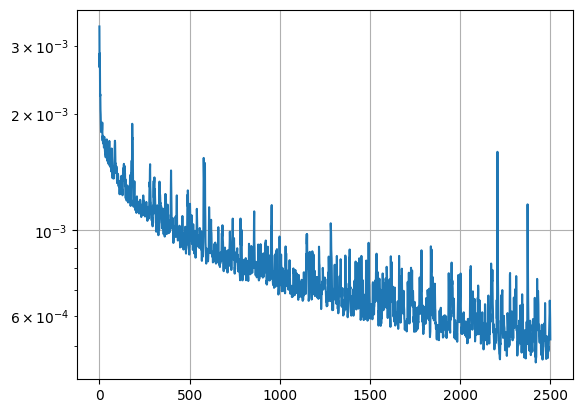

In [85]:
epochs = 2500
CHVparams, CHVloss = CHVtrain_network(CHVparams, Hde_points, Hzsensors, epochs)

plt.semilogy(CHVloss)
plt.grid()

0.004462160670744258 0.003378227557856193


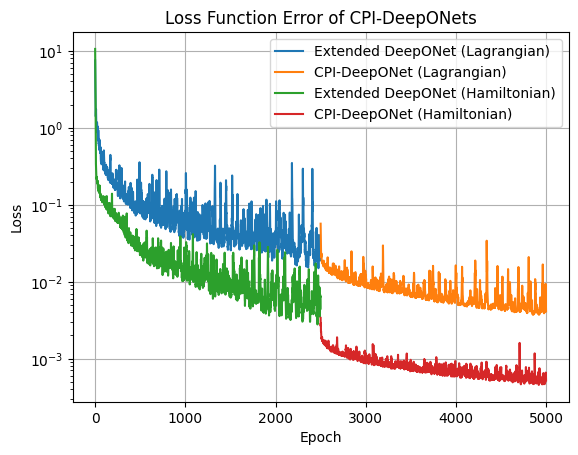

In [86]:
split = 2500
num_ep = np.arange(0, split, 1)
Cnum_ep = np.arange(split, split + epochs, 1)

print(Hloss[-1], CHVloss[0])

plt.semilogy(num_ep, loss)
plt.semilogy(Cnum_ep, CVloss)
plt.semilogy(num_ep, Hloss)
plt.semilogy(Cnum_ep, CHVloss)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss Function Error of CPI-DeepONets")
plt.legend(['Extended DeepONet (Lagrangian)', 'CPI-DeepONet (Lagrangian)', 'Extended DeepONet (Hamiltonian)', 'CPI-DeepONet (Hamiltonian)'])
plt.grid()
#plt.savefig('DoublePend_cpi+Hcpi_loss_2500+2500ep.png')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


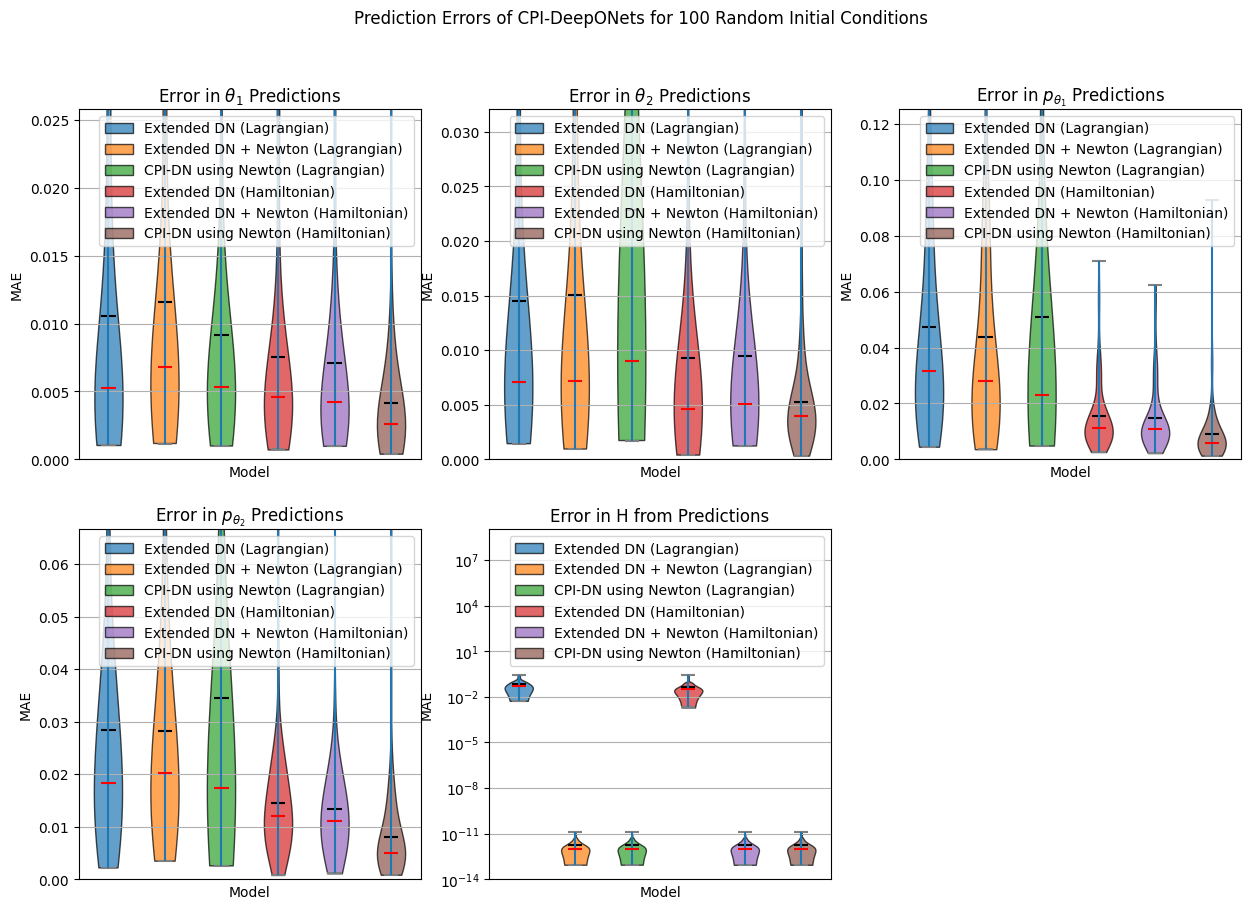

In [132]:
def run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, H_models_lst, newton_H_lst, newton_E_lst) :

    
    n = 500
    t = np.linspace(t0, tfinal, n)
        
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    bound = 1.0
        
    for i in range(num_exp) :

        print(i)

        Hy1_init, Hy2_init = 10.0, 10.0

        while abs(Hy1_init) > bound or abs(Hy2_init) > bound :

            x1_init = np.random.uniform(-bound, bound, size=(1,))
            x2_init = np.random.uniform(-bound, bound, size=(1,))
            y1_init = np.random.uniform(-bound, bound, size=(1,))
            y2_init = np.random.uniform(-bound, bound, size=(1,))
            Hy1_init, Hy2_init = Hcalc_y1y2(x1_init, x2_init, y1_init, y2_init)
        
        E_init = calc_E(x1_init, x2_init, y1_init, y2_init)
        H_init = Hcalc_H(x1_init, x2_init, Hy1_init, Hy2_init)

        data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        Hdata_model = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
        Hdata_model = np.reshape(Hdata_model, (-1,))
        Hdata_model = np.repeat(np.expand_dims(Hdata_model, axis=0), n, axis=0)

        E_data = np.reshape(E_init, (-1,))
        E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
        
        H_data = np.reshape(H_init, (-1,))
        H_data = np.repeat(np.expand_dims(H_data, axis=0), n, axis=0)
        
        tE_model = np.column_stack([t, E_data])
        tH_model = np.column_stack([t, H_data])  

        
        data_rk = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
            
        sol_rk = odeint(HdoublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1_rk, x2_rk, Hy1_rk, Hy2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
        H_rk = Hcalc_H(x1_rk, x2_rk, Hy1_rk, Hy2_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - num_cons) :

                if j not in H_models_lst :

                    val = jax.vmap(model, [0, 0, None, None])(tE_model, data_model, k, params)
                    preds[i, j, k] = val

                else:
   
                    val = jax.vmap(model, [0, 0, None, None])(tH_model, Hdata_model, k, params)
                    preds[i, j, k] = val

                
            if j not in H_models_lst:

                preds[i, j, 4] = calc_E(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])

            else:
                
                preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])

            
            if j in newton_H_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                H_arr = tH_model[:, 1:]
            
                xnewtonH = find_min_newton_H(args_arr, H_arr)                
            
                for l in range(num_vars - num_cons) :
            
                    preds[i, j, l] = xnewtonH[:, l]
            
                
                preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
           
            
            if j in newton_E_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                E_arr = tE_model[:, 1:]
            
                xnewtonE = find_min_newton_E(args_arr, E_arr)                
            
                for l in range(num_vars - num_cons) :
            
                    preds[i, j, l] = xnewtonE[:, l]

                preds[i, j, 4] = calc_E(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
                

            if j not in H_models_lst :

                preds[i, j, 2], preds[i, j, 3] = Hcalc_y1y2(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
                preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
              

            for m in range(num_vars - num_cons) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 4] = np.mean(np.abs(H_rk - preds[i, j, 4]))          


    x_labels = [r'$\theta_1$', r'$\theta_2$', r'$p_{\theta_1}$', r'$p_{\theta_2}$', 'H']
        
    # Set up the figure
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle('Prediction Errors of CPI-DeepONets for 100 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']   # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(2, 3, j + 1)
    
        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1
    
        plt.ylim(0.0, q3 + 1.5 * iqr)
    
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
    
        # Create the violin plot with custom colors            
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
            
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
    
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')  # Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 4:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label
    
        # Set the y scale to logarithmic for j == 4
        if j == 4:
            plt.yscale('log')
            plt.ylim(10**(-14), 10**9)
            
        plt.legend(labels=labels_lst, loc='upper right')

    

    
    # fig.savefig('doublepend_cpi+hcpi_2500+2500ep_100exps.png')
    return preds, preds_error, (x1_rk, x2_rk, Hy1_rk, Hy2_rk, H_rk)


preds, preds_error, (x1_rk, x2_rk, Hy1_rk, Hy2_rk, H_rk) = run_test(num_vars = 5, num_cons = 1, num_models = 6, num_exp = 100, \
         models_lst = [var_model, var_model, CVvar_model, Hvar_model, Hvar_model, CHVvar_model], \
         params_lst = [params_5000ep, params_5000ep, CVparams, Hparams_5000ep, Hparams_5000ep, CHVparams], \
         labels_lst = ['Extended DN (Lagrangian)', 'Extended DN + Newton (Lagrangian)', 'CPI-DN using Newton (Lagrangian)',  \
                       'Extended DN (Hamiltonian)', 'Extended DN + Newton (Hamiltonian)',  'CPI-DN using Newton (Hamiltonian)'], \
         # models_lst = [Vvar_model, var_model, HVvar_model, Hvar_model], \
         # params_lst = [Vparams, params, HVparams, Hparams], \
         # labels_lst = ['Vanilla DN (Lagrangian)', 'Extended DN (Lagrangian)', 'Vanilla DN (Hamiltonian)', 'Extended DN (Hamiltonian)'], \
         H_models_lst = [3, 4, 5], 
         newton_H_lst = [4],
         newton_E_lst = [1])

Exp: 0
Exp: 1
Exp: 2
Exp: 3
Exp: 4
Exp: 5
Exp: 6
Exp: 7
Exp: 8
Exp: 9
Exp: 10
Exp: 11
Exp: 12
Exp: 13
Exp: 14
Exp: 15
Exp: 16
Exp: 17
Exp: 18
Exp: 19
Exp: 20
Exp: 21
Exp: 22
Exp: 23
Exp: 24
Exp: 25
Exp: 26
Exp: 27
Exp: 28
Exp: 29
Exp: 30
Exp: 31
Exp: 32
Exp: 33
Exp: 34
Exp: 35
Exp: 36
Exp: 37
Exp: 38
Exp: 39
Exp: 40
Exp: 41
Exp: 42
Exp: 43
Exp: 44
Exp: 45
Exp: 46
Exp: 47
Exp: 48
Exp: 49


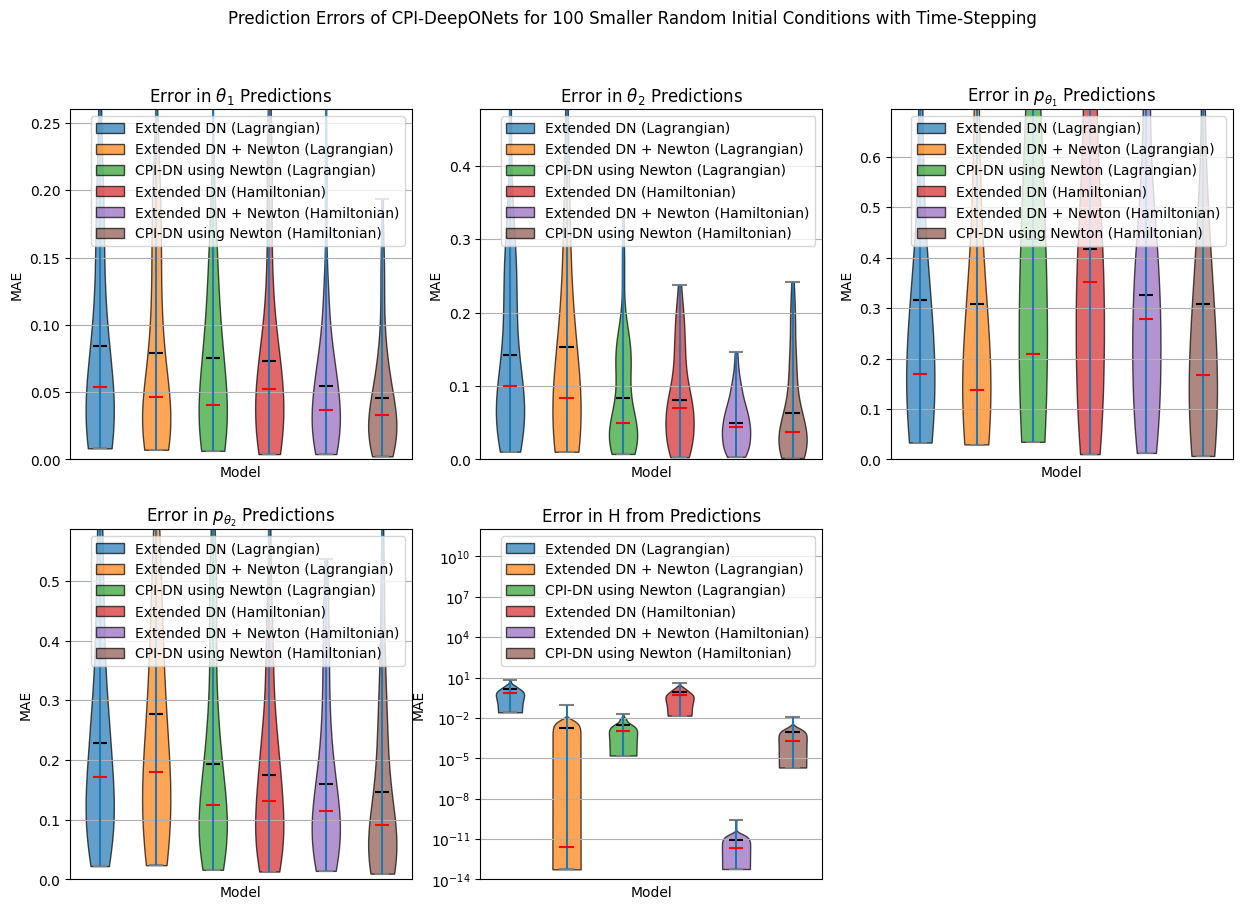

In [95]:
def tt_run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, H_models_lst, newton_H_lst, newton_E_lst, t_end) :

    n = 500

    num_extra = 3
    step_extra = 5
    

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    bound = 1.0
    
    for i in range(num_exp) :

        print("Exp:", i)

        Hy1_init, Hy2_init = 10.0, 10.0

        while abs(Hy1_init) > bound or abs(Hy2_init) > bound :

            x1_init = np.random.uniform(-bound, bound, size=(1,))
            x2_init = np.random.uniform(-bound, bound, size=(1,))
            y1_init = np.random.uniform(-bound, bound, size=(1,))
            y2_init = np.random.uniform(-bound, bound, size=(1,))
            Hy1_init, Hy2_init = Hcalc_y1y2(x1_init, x2_init, y1_init, y2_init)
        
        E_init = calc_E(x1_init, x2_init, y1_init, y2_init)
        H_init = Hcalc_H(x1_init, x2_init, Hy1_init, Hy2_init)

        data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        Hdata_model = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
        Hdata_model = np.reshape(Hdata_model, (-1,))
        Hdata_model_0 = np.repeat(np.expand_dims(Hdata_model, axis=0), n, axis=0)

        E_data = np.reshape(E_init, (-1,))
        E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
        
        H_data = np.reshape(H_init, (-1,))
        H_data = np.repeat(np.expand_dims(H_data, axis=0), n, axis=0)

        t = np.linspace(t0, tfinal, n)
        
        tE_model_0 = np.column_stack([t, E_data])
        tH_model_0 = np.column_stack([t, H_data])  

        data_rk = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
            
        sol_rk = odeint(HdoublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1_rk, x2_rk, Hy1_rk, Hy2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
        H_rk = Hcalc_H(x1_rk, x2_rk, Hy1_rk, Hy2_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for c in range(num_cycles) :

                tE_model_lst = []
                data_model_lst = []

                tH_model_lst = []
                Hdata_model_lst = []

                if c != 0 :

                    if j not in H_models_lst:

                        for m in range(num_extra + 1) :

                            x1_init = preds[i, j, c - 1, 0, -(1 + m*step_extra)]
                            x2_init = preds[i, j, c - 1, 1, -(1 + m*step_extra)]
                            y1_init = preds[i, j, c - 1, 2, -(1 + m*step_extra)]
                            y2_init = preds[i, j, c - 1, 3, -(1 + m*step_extra)]
        
                            E_init = calc_E(x1_init, x2_init, y1_init, y2_init)
                            
                            data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
                            data_model = np.reshape(data_model, (-1,))
                            data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1 + m*step_extra, axis=0)
                    
                            E_model = np.repeat(np.expand_dims(E_init, axis=0), n + 1 + m*step_extra, axis=0)
                                
                            t = np.linspace(t0, tfinal + (1 + m*step_extra)*t_step, n + 1 + m*step_extra)
                                    
                            tE_model = np.column_stack([t, E_model])

                            data_model_lst.append(data_model)
                            tE_model_lst.append(tE_model)

                    else :

                        for m in range(num_extra + 1) :

                            x1_init = preds[i, j, c - 1, 0, -(1 + m*step_extra)]
                            x2_init = preds[i, j, c - 1, 1, -(1 + m*step_extra)]
                            Hy1_init = preds[i, j, c - 1, 2, -(1 + m*step_extra)]
                            Hy2_init = preds[i, j, c - 1, 3, -(1 + m*step_extra)]
        
                            H_init = Hcalc_H(x1_init, x2_init, Hy1_init, Hy2_init)
                            
                            Hdata_model = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
                            Hdata_model = np.reshape(Hdata_model, (-1,))
                            Hdata_model = np.repeat(np.expand_dims(Hdata_model, axis=0), n + 1 + m*step_extra, axis=0)
                    
                            H_model = np.repeat(np.expand_dims(H_init, axis=0), n + 1 + m*step_extra, axis=0)
                                
                            t = np.linspace(t0, tfinal + (1 + m*step_extra)*t_step, n + 1 + m*step_extra)
                                    
                            tH_model = np.column_stack([t, H_model])

                            Hdata_model_lst.append(Hdata_model)
                            tH_model_lst.append(tH_model)

                else:

                    data_model = data_model_0
                    tE_model = tE_model_0
                    data_model_lst.append(data_model)
                    tE_model_lst.append(tE_model)
                    
                    Hdata_model = Hdata_model_0
                    tH_model = tH_model_0
                    Hdata_model_lst.append(Hdata_model)
                    tH_model_lst.append(tH_model)
                        
                for k in range(num_vars - num_cons) :

                    val_lst = []
    
                    if j not in H_models_lst :

                        for m in range(num_extra + 1) :
                        
                            val = jax.vmap(model, [0, 0, None, None])(tE_model_lst[m], data_model_lst[m], k, params)
                            val_lst.append(val[-n:])

                            if c == 0 :
                                break

                        val = jnp.mean(jnp.stack(val_lst), axis=0)
                    
                    else:
   
                        for m in range(num_extra + 1) :
                        
                            val = jax.vmap(model, [0, 0, None, None])(tH_model_lst[m], Hdata_model_lst[m], k, params)
                            val_lst.append(val[-n:])

                            if c == 0:
                                break

                        val = jnp.mean(jnp.stack(val_lst), axis=0)

                    preds[i, j, c, k] = val
                        
    
                if j not in H_models_lst:
    
                    preds[i, j, c, 4] = calc_E(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])
    
                else:
                    
                    preds[i, j, c, 4] = Hcalc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])


                if j in newton_H_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3]])
                    H_arr = tH_model[:, 1:] if c == 0 else tH_model[-n:, 1:]
                
                    xnewtonH = find_min_newton_H(args_arr, H_arr)                
                
                    for l in range(num_vars - num_cons) :
                
                        preds[i, j, c, l] = xnewtonH[:, l]
                
                    
                    preds[i, j, c, 4] = Hcalc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])


                if j in newton_E_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3]])
                    E_arr = tE_model[:, 1:] if c == 0 else tE_model[-n:, 1:]
                
                    xnewtonE = find_min_newton_E(args_arr, E_arr)                
                
                    for l in range(num_vars - num_cons) :
                
                        preds[i, j, c, l] = xnewtonE[:, l]
    
                    preds[i, j, c, 4] = calc_E(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])


                
            if j not in H_models_lst :

                preds[i, j, :, 2], preds[i, j, :, 3] = Hcalc_y1y2(preds[i, j, :, 0], preds[i, j, :, 1], preds[i, j, :, 2], preds[i, j, :, 3])
                preds[i, j, :, 4] = Hcalc_H(preds[i, j, :, 0], preds[i, j, :, 1], preds[i, j, :, 2], preds[i, j, :, 3])

                                     
            for m in range(num_vars - num_cons) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 4] = np.mean(np.abs(H_rk - preds[i, j, :, 4].flatten()))          
            
    
    x_labels = [r'$\theta_1$', r'$\theta_2$', r'$p_{\theta_1}$', r'$p_{\theta_2}$', 'H']
        
    # Set up the figure
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle('Prediction Errors of CPI-DeepONets for 100 Smaller Random Initial Conditions with Time-Stepping')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']   # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(2, 3, j + 1)
    
        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1
    
        plt.ylim(0.0, q3 + 1.5 * iqr)
    
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
    
        # Create the violin plot with custom colors            
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
            
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
    
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')  # Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 4:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label
    
        # Set the y scale to logarithmic for j == 4
        if j == 4:
            plt.yscale('log')
            plt.ylim(10**-14, 10**12)
            
        plt.legend(labels=labels_lst, loc='upper right')

    
    # fig.savefig('doublepend_tt3.0_cpi+hcpi_violinmae_2500+2500ep_100exps_smallang.png')
    return preds, preds_error, (x1_rk, x2_rk, Hy1_rk, Hy2_rk, H_rk)


t_end_val = 1.5

preds, preds_error, (x1_rk, x2_rk, Hy1_rk, Hy2_rk, H_rk) = tt_run_test(num_vars = 5, num_cons = 1, num_models = 6, num_exp = 50, \
         models_lst = [var_model, var_model, CVvar_model, Hvar_model, Hvar_model, CHVvar_model], \
         params_lst = [params_5000ep, params_5000ep, CVparams, Hparams_5000ep, Hparams_5000ep, CHVparams], \
         labels_lst = ['Extended DN (Lagrangian)', 'Extended DN + Newton (Lagrangian)', 'CPI-DN using Newton (Lagrangian)',  \
                       'Extended DN (Hamiltonian)', 'Extended DN + Newton (Hamiltonian)',  'CPI-DN using Newton (Hamiltonian)'], \
         # models_lst = [Vvar_model, var_model, HVvar_model, Hvar_model], \
         # params_lst = [Vparams, params, HVparams, Hparams], \
         # labels_lst = ['Vanilla DN (Lagrangian)', 'Extended DN (Lagrangian)', 'Vanilla DN (Hamiltonian)', 'Extended DN (Hamiltonian)'], \
         H_models_lst = [3, 4, 5], 
         newton_H_lst = [4],
         newton_E_lst = [1],
         t_end = t_end_val)

Exp: 0
Exp: 1
Exp: 2
Exp: 3
Exp: 4
Exp: 5
Exp: 6
Exp: 7
Exp: 8
Exp: 9
Exp: 10
Exp: 11
Exp: 12
Exp: 13
Exp: 14
Exp: 15
Exp: 16
Exp: 17
Exp: 18
Exp: 19
Exp: 20
Exp: 21
Exp: 22
Exp: 23
Exp: 24
Exp: 25
Exp: 26
Exp: 27
Exp: 28
Exp: 29
Exp: 30
Exp: 31
Exp: 32
Exp: 33
Exp: 34
Exp: 35
Exp: 36
Exp: 37
Exp: 38
Exp: 39
Exp: 40
Exp: 41
Exp: 42
Exp: 43
Exp: 44
Exp: 45
Exp: 46
Exp: 47
Exp: 48
Exp: 49


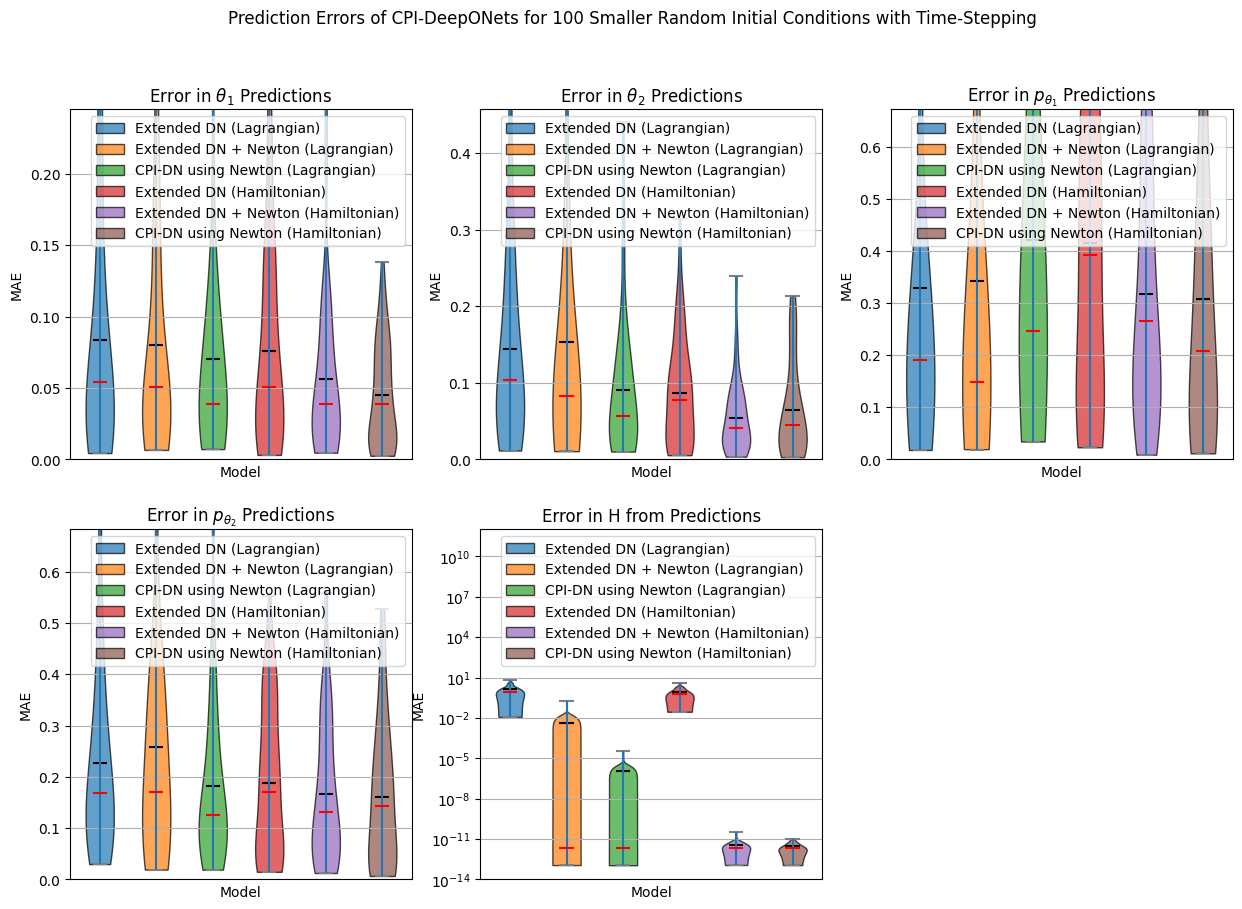

In [96]:
def tt_run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, H_models_lst, newton_H_lst, newton_E_lst, t_end) :

    n = 500

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    bound = 1.0
    
    for i in range(num_exp) :

        print("Exp:", i)

        Hy1_init, Hy2_init = 10.0, 10.0

        while abs(Hy1_init) > bound or abs(Hy2_init) > bound :

            x1_init = np.random.uniform(-bound, bound, size=(1,))
            x2_init = np.random.uniform(-bound, bound, size=(1,))
            y1_init = np.random.uniform(-bound, bound, size=(1,))
            y2_init = np.random.uniform(-bound, bound, size=(1,))
            Hy1_init, Hy2_init = Hcalc_y1y2(x1_init, x2_init, y1_init, y2_init)
        
        E_init = calc_E(x1_init, x2_init, y1_init, y2_init)
        H_init = Hcalc_H(x1_init, x2_init, Hy1_init, Hy2_init)

        data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        Hdata_model = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
        Hdata_model = np.reshape(Hdata_model, (-1,))
        Hdata_model_0 = np.repeat(np.expand_dims(Hdata_model, axis=0), n, axis=0)

        E_data = np.reshape(E_init, (-1,))
        E_data = np.repeat(np.expand_dims(E_data, axis=0), n, axis=0)
        
        H_data = np.reshape(H_init, (-1,))
        H_data = np.repeat(np.expand_dims(H_data, axis=0), n, axis=0)

        t = np.linspace(t0, tfinal, n)
        
        tE_model_0 = np.column_stack([t, E_data])
        tH_model_0 = np.column_stack([t, H_data])  

        data_rk = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
            
        sol_rk = odeint(HdoublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1_rk, x2_rk, Hy1_rk, Hy2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
        H_rk = Hcalc_H(x1_rk, x2_rk, Hy1_rk, Hy2_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for c in range(num_cycles) :

                # print("Cyc:", c)

                if c != 0 :

                    if j not in H_models_lst:

                        x1_init = preds[i, j, c - 1, 0, -1]
                        x2_init = preds[i, j, c - 1, 1, -1]
                        y1_init = preds[i, j, c - 1, 2, -1]
                        y2_init = preds[i, j, c - 1, 3, -1]
    
                        E_init = calc_E(x1_init, x2_init, y1_init, y2_init)
                        
                        data_model = np.column_stack([x1_init, x2_init, y1_init, y2_init])
                        data_model = np.reshape(data_model, (-1,))
                        data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1, axis=0)
                
                        E_model = np.repeat(np.expand_dims(E_init, axis=0), n + 1, axis=0)
                            
                        t = np.linspace(t0, tfinal + t_step, n + 1)
                                
                        tE_model = np.column_stack([t, E_model])

                    else :

                        x1_init = preds[i, j, c - 1, 0, -1]
                        x2_init = preds[i, j, c - 1, 1, -1]
                        Hy1_init = preds[i, j, c - 1, 2, -1]
                        Hy2_init = preds[i, j, c - 1, 3, -1]
    
                        H_init = Hcalc_H(x1_init, x2_init, Hy1_init, Hy2_init)
                        
                        Hdata_model = np.column_stack([x1_init, x2_init, Hy1_init, Hy2_init])
                        Hdata_model = np.reshape(Hdata_model, (-1,))
                        Hdata_model = np.repeat(np.expand_dims(Hdata_model, axis=0), n + 1, axis=0)
                
                        H_model = np.repeat(np.expand_dims(H_init, axis=0), n + 1, axis=0)
                            
                        t = np.linspace(t0, tfinal + t_step, n + 1)
                                
                        tH_model = np.column_stack([t, H_model])    

                else:

                    data_model = data_model_0
                    tE_model = tE_model_0

                    Hdata_model = Hdata_model_0
                    tH_model = tH_model_0

                        
                for k in range(num_vars - num_cons) :
    
                    if j not in H_models_lst :

                        val = jax.vmap(model, [0, 0, None, None])(tE_model, data_model, k, params)
                    
                    else:
   
                        val = jax.vmap(model, [0, 0, None, None])(tH_model, Hdata_model, k, params)

                    if c != 0 :
                        preds[i, j, c, k] = val[1:]

                    else:
                        preds[i, j, c, k] = val
                        
    
                if j not in H_models_lst:
    
                    preds[i, j, c, 4] = calc_E(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])
    
                else:
                    
                    preds[i, j, c, 4] = Hcalc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])


                if j in newton_H_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3]])
                    H_arr = tH_model[:, 1:] if c == 0 else tH_model[1:, 1:]
                
                    xnewtonH = find_min_newton_H(args_arr, H_arr)                
                
                    for l in range(num_vars - num_cons) :
                
                        preds[i, j, c, l] = xnewtonH[:, l]
                
                    
                    preds[i, j, c, 4] = Hcalc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])


                if j in newton_E_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3]])
                    E_arr = tE_model[:, 1:] if c == 0 else tE_model[1:, 1:]
                
                    xnewtonE = find_min_newton_E(args_arr, E_arr)                
                
                    for l in range(num_vars - num_cons) :
                
                        preds[i, j, c, l] = xnewtonE[:, l]
    
                    preds[i, j, c, 4] = calc_E(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])


                
            if j not in H_models_lst :

                preds[i, j, :, 2], preds[i, j, :, 3] = Hcalc_y1y2(preds[i, j, :, 0], preds[i, j, :, 1], preds[i, j, :, 2], preds[i, j, :, 3])
                preds[i, j, :, 4] = Hcalc_H(preds[i, j, :, 0], preds[i, j, :, 1], preds[i, j, :, 2], preds[i, j, :, 3])

                                     
            for m in range(num_vars - num_cons) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 4] = np.mean(np.abs(H_rk - preds[i, j, :, 4].flatten()))          
            
    
    x_labels = [r'$\theta_1$', r'$\theta_2$', r'$p_{\theta_1}$', r'$p_{\theta_2}$', 'H']
        
    # Set up the figure
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle('Prediction Errors of CPI-DeepONets for 100 Smaller Random Initial Conditions with Time-Stepping')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']   # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(2, 3, j + 1)
    
        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1
    
        plt.ylim(0.0, q3 + 1.5 * iqr)
    
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
    
        # Create the violin plot with custom colors            
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
            
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
    
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')  # Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 4:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label
    
        # Set the y scale to logarithmic for j == 4
        if j == 4:
            plt.yscale('log')
            plt.ylim(10**-14, 10**12)
            
        plt.legend(labels=labels_lst, loc='upper right')

    
    # fig.savefig('doublepend_tt3.0_cpi+hcpi_violinmae_2500+2500ep_100exps_smallang.png')
    return preds, preds_error, (x1_rk, x2_rk, Hy1_rk, Hy2_rk, H_rk)


t_end_val = 1.5

preds, preds_error, (x1_rk, x2_rk, Hy1_rk, Hy2_rk, H_rk) = tt_run_test(num_vars = 5, num_cons = 1, num_models = 6, num_exp = 50, \
         models_lst = [var_model, var_model, CVvar_model, Hvar_model, Hvar_model, CHVvar_model], \
         params_lst = [params_5000ep, params_5000ep, CVparams, Hparams_5000ep, Hparams_5000ep, CHVparams], \
         labels_lst = ['Extended DN (Lagrangian)', 'Extended DN + Newton (Lagrangian)', 'CPI-DN using Newton (Lagrangian)',  \
                       'Extended DN (Hamiltonian)', 'Extended DN + Newton (Hamiltonian)',  'CPI-DN using Newton (Hamiltonian)'], \
         # models_lst = [Vvar_model, var_model, HVvar_model, Hvar_model], \
         # params_lst = [Vparams, params, HVparams, Hparams], \
         # labels_lst = ['Vanilla DN (Lagrangian)', 'Extended DN (Lagrangian)', 'Vanilla DN (Hamiltonian)', 'Extended DN (Hamiltonian)'], \
         H_models_lst = [3, 4, 5], 
         newton_H_lst = [4],
         newton_E_lst = [1],
         t_end = t_end_val)

In [219]:
# num_vars = 5
# num_models = 6

# labels_lst = ['Extended DN (Lagrangian)', 'Extended DN + Newton (Lagrangian)', 'CPI-DN using Newton (Lagrangian)',  \
#               'Extended DN (Hamiltonian)', 'Extended DN + Newton (Hamiltonian)',  'CPI-DN using Newton (Hamiltonian)']

# x_labels = [r'$\theta_1$', r'$\theta_2$', r'$p_{\theta_1}$', r'$p_{\theta_2}$', 'H']
    
# # Set up the figure
# fig = plt.figure(figsize=(15, 10))
# fig.suptitle('Prediction Errors of CPI-DeepONets for 100 Smaller Random Initial Conditions with Time-Stepping')

# # Define colors for each model (adjust color palette as needed)
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']   # Example colors for each model

# for j in range(num_vars):
#     plt.subplot(2, 3, j + 1)

#     # q1 = np.percentile(preds_error[:, 2, j], 25)
#     q3 = np.percentile(preds_error[:, 2, j], 75)
#     iqr = q3 - q1

#     plt.ylim(0.0, q3 + 2.5 * iqr)

#     # Prepare data for each model for the current variable (j)
#     data = [preds_error[:, alpha, j] for alpha in range(num_models)]

#     # Create the violin plot with custom colors            
#     vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
#     # Customize the colors of the violins
#     for i in range(num_models):
#         vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
#         vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
#         vp['bodies'][i].set_alpha(0.7)            # Set transparency

#     # Customize mean and median lines
#     vp['cmeans'].set_color('black')  # Mean line color
#     vp['cmedians'].set_color('red')
#     vp['cmins'].set_color('gray')
#     vp['cmaxes'].set_color('gray')  # Median line color

#     # Add labels, title, and grid
#     plt.ylabel("MAE")
#     if j >= 4:
#         plt.title("Error in " + x_labels[j] + " from Predictions")
#     else:
#         plt.title("Error in " + x_labels[j] + " Predictions")
#     plt.grid(True, axis='y')

#     # Add legend (outside the plot)
#     plt.xticks([])  # Remove vertical axis ticks
#     plt.xlabel("Model")  # Remove vertical axis label

#     # Set the y scale to logarithmic for j == 4
#     if j == 4:
#         plt.yscale('log')
#         plt.ylim(10**-14, 10**12)
        
#     plt.legend(labels=labels_lst, loc='upper right')


# fig.savefig('doublepend_tt3.0_cpi+hcpi_violinmae_2500+2500ep_100exps_smallang.png')

In [220]:
# # num_exp, num_models, num_cycles, num_vars, n
# num_exp, num_models, num_vars
# print(preds[0, 0, :, 1, :])

#plt.plot(preds[0, 0, 0, 1, :])
#plt.plot(preds[0, 0, 1, -1, :])
#print(preds_error[:, 1, -1])

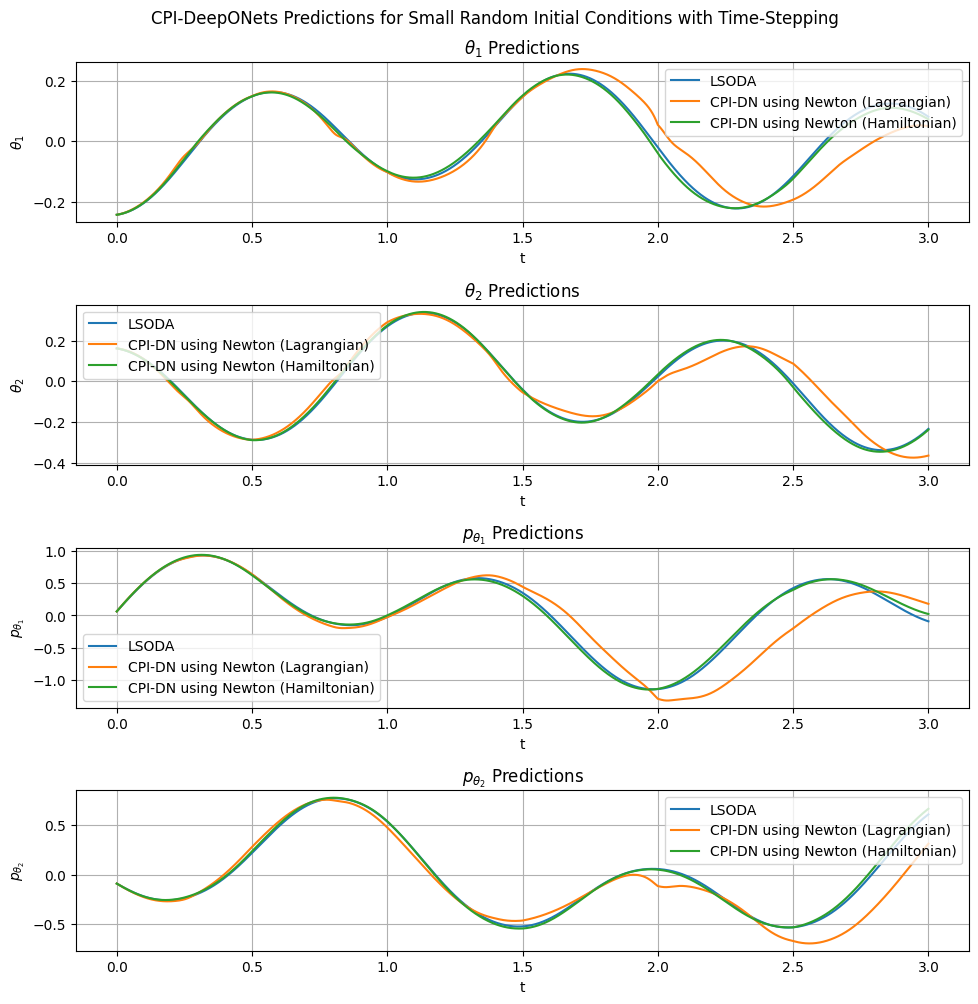

In [222]:
n = 500
t_end = t_end_val

num_cycles = int(t_end/tfinal)
n_tot = n*num_cycles
t_tot = np.linspace(t0, t_end, n_tot)


# Vx1, Vx2, Vy1, Vy2, VE = preds[-1, 3, :, 0, :], preds[-1, 3, :, 1, :], preds[-1, 3, :, 2, :], preds[-1, 3, :, 3, :], preds[-1, 3, :, 4, :]
# BVx1, BVx2, BVy1, BVy2, BVE = preds[-1, 4, :, 0, :], preds[-1, 4, :, 1, :], preds[-1, 4, :, 2, :], preds[-1, 4, :, 3, :], preds[-1, 4, :, 4, :]
Cx1, Cx2, CHy1, CHy2, CH = preds[-1, 2, :, 0, :], preds[-1, 2, :, 1, :], preds[-1, 2, :, 2, :], preds[-1, 2, :, 3, :], preds[-1, 2, :, 4, :]
CHx1, CHx2, CHHy1, CHHy2, CHH = preds[-1, 5, :, 0, :], preds[-1, 5, :, 1, :], preds[-1, 5, :, 2, :], preds[-1, 5, :, 3, :], preds[-1, 5, :, 4, :]

fig = plt.figure(figsize=(10, 10))
fig.suptitle('CPI-DeepONets Predictions for Small Random Initial Conditions with Time-Stepping')


plt.subplot(4, 1, 1)
plt.tight_layout()
plt.plot(t_tot, x1_rk)
# plt.plot(t_tot, Vx1.flatten())
# plt.plot(t_tot, BVx1.flatten())
plt.plot(t_tot, Cx1.flatten())
plt.plot(t_tot, CHx1.flatten())
plt.xlabel("t")
plt.ylabel(r'$\theta_1$')
plt.grid()
plt.legend(['LSODA', 'CPI-DN using Newton (Lagrangian)', 'CPI-DN using Newton (Hamiltonian)'])
plt.title(r'$\theta_1$' + " Predictions")

plt.subplot(4, 1, 2)
plt.tight_layout()
plt.plot(t_tot, x2_rk)
# plt.plot(t_tot, Vx2.flatten())
# plt.plot(t_tot, BVx2.flatten())
plt.plot(t_tot, Cx2.flatten())
plt.plot(t_tot, CHx2.flatten())
plt.xlabel("t")
plt.ylabel(r'$\theta_2$')
plt.grid()
plt.legend(['LSODA', 'CPI-DN using Newton (Lagrangian)', 'CPI-DN using Newton (Hamiltonian)'])
plt.title(r'$\theta_2$' + " Predictions")


plt.subplot(4, 1, 3)
plt.tight_layout()
plt.plot(t_tot, Hy1_rk)
# plt.plot(t_tot, Vy1.flatten())
# plt.plot(t_tot, BVy1.flatten())
plt.plot(t_tot, CHy1.flatten())
plt.plot(t_tot, CHHy1.flatten())
plt.xlabel("t")
plt.ylabel(r'$p_{\theta_1}$')
plt.grid()
plt.legend(['LSODA', 'CPI-DN using Newton (Lagrangian)', 'CPI-DN using Newton (Hamiltonian)'])
plt.title(r'$p_{\theta_1}$' + " Predictions")



plt.subplot(4, 1, 4)
plt.tight_layout()
plt.plot(t_tot, Hy2_rk)
# plt.plot(t_tot, Vy2.flatten())
# plt.plot(t_tot, BVy2.flatten())
plt.plot(t_tot, CHy2.flatten())
plt.plot(t_tot, CHHy2.flatten())
plt.xlabel("t")
plt.ylabel(r'$p_{\theta_2}$')
plt.grid()
plt.legend(['LSODA', 'CPI-DN using Newton (Lagrangian)', 'CPI-DN using Newton (Hamiltonian)'])
plt.title(r'$p_{\theta_2}$' + " Predictions")






         
# plt.subplot(1, 5, 4)
# plt.tight_layout()
# plt.plot(t_tot, E_rk)
# #plt.plot(t_tot, E.flatten())
# plt.plot(t_tot, E_bfgs.flatten())
# plt.plot(t_tot, CE.flatten())
# plt.xlabel("t")
# plt.ylabel("E")
# plt.grid()
# plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
# plt.title("E from Predictions")


# plt.subplot(1, 5, 5)
# plt.tight_layout()
# plt.plot(t_tot, V_rk)
# #plt.plot(t_tot, V.flatten())
# plt.plot(t_tot, V_bfgs.flatten())
# plt.plot(t_tot, CV.flatten())
# plt.xlabel("t")
# plt.ylabel("V")
# plt.grid()
# plt.legend(['LSODA', 'Extended DN', 'Extended DN + BFGS', 'CPI-DeepONet'])
# plt.title("V from Predictions")

plt.show()
#fig.savefig('doublepend_tt3.0_cpi+hcpi_preds_2500+2500ep_smallang.png')